# **_Proyecto KDD - Metodologia de Analitica de Datos_**

**IMPORTACIÓN DE LIBRERÍAS**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

**FASE 1: SELECCIÓN DE DATOS**

In [12]:
print("FASE 1: SELECCIÓN DE DATOS")

# Cargar datos
df = pd.read_csv('salaries.csv')

print(f" Dimensiones del dataset: {df.shape}")
print(f"\n Columnas disponibles:\n{df.columns.tolist()}")
print(f"\n Primeras 5 filas:")
print(df.head())
print(f"\n Tipos de datos:\n{df.dtypes}")

FASE 1: SELECCIÓN DE DATOS
 Dimensiones del dataset: (73148, 11)

 Columnas disponibles:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

 Primeras 5 filas:
   work_year experience_level employment_type           job_title  salary  \
0       2025               SE              FT  Data Product Owner  170000   
1       2025               SE              FT  Data Product Owner  110000   
2       2025               SE              FT  Data Product Owner  170000   
3       2025               SE              FT  Data Product Owner  110000   
4       2025               SE              FT            Engineer  143000   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             USD         170000                 US             0   
1             USD         110000                 US             0   
2             USD         170000   

**FASE 2: PREPROCESAMIENTO Y LIMPIEZA**

In [13]:
print("FASE 2: PREPROCESAMIENTO Y LIMPIEZA")

# 1. Verificar valores nulos
print(f"\n Valores nulos por columna:\n{df.isnull().sum()}")

# 2. Verificar duplicados
duplicates = df.duplicated().sum()
print(f"\n Registros duplicados: {duplicates}")

# 3. Eliminar duplicados (si existen)
df = df.drop_duplicates()
print(f" Dimensiones después de eliminar duplicados: {df.shape}")

# 4. Estadísticas completas
print(f"\n Estadísticas descriptivas completas:")
print(df.describe(include='all'))

# 5. Outliers: Detección pero NO eliminación
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['salary_in_usd'] < lower_bound) | (df['salary_in_usd'] > upper_bound)]

print(f"\n Outliers detectados en salario: {len(outliers)} registros")
print("\n NOTA: Se detectaron valores extremos mediante IQR; sin embargo, se conservaron")
print("   por representar salarios reales de cargos ejecutivos (Directores de IA, VP, etc.)")
print(f"   Ejemplos: {outliers['job_title'].value_counts().head(5)}")

FASE 2: PREPROCESAMIENTO Y LIMPIEZA

 Valores nulos por columna:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

 Registros duplicados: 39124
 Dimensiones después de eliminar duplicados: (34024, 11)

 Estadísticas descriptivas completas:
           work_year experience_level employment_type       job_title  \
count   34024.000000            34024           34024           34024   
unique           NaN                4               4             289   
top              NaN               SE              FT  Data Scientist   
freq             NaN            18074           33721            4316   
mean     2023.785622              NaN             NaN             NaN   
std         0.567422              NaN             NaN             NaN   
min      2020.000000 

**FASE 3: TRANSFORMACIÓN DE DATOS**

In [14]:
print("FASE 3: TRANSFORMACIÓN DE DATOS")

# 1. Crear copia para transformaciones
df_encoded = df.copy()

# 2. One-Hot Encoding para variables categóricas (CORRECCIÓN: usar OneHotEncoder)
categorical_features = ['job_title', 'employment_type', 'experience_level',
                        'company_size', 'employee_residence', 'company_location']

# Crear columnas one-hot
for col in categorical_features:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)

print(f" Variables categóricas transformadas con One-Hot Encoding")
print(f" Nuevas dimensiones: {df_encoded.shape}")

# 3. Crear categorías de salario para análisis
df_encoded['salary_category'] = pd.cut(df_encoded['salary_in_usd'],
                                        bins=[0, 70000, 120000, 200000, float('inf')],
                                        labels=['Bajo (<70k)', 'Medio (70-120k)',
                                                'Alto (120-200k)', 'Ejecutivo (>200k)'])

# 4. Escalar variables numéricas para modelos
scaler = StandardScaler()
numeric_features = ['salary_in_usd', 'remote_ratio', 'work_year']
df_encoded_scaled = df_encoded.copy()
df_encoded_scaled[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

print("\n Variables numéricas escaladas")

FASE 3: TRANSFORMACIÓN DE DATOS
 Variables categóricas transformadas con One-Hot Encoding
 Nuevas dimensiones: (34024, 484)

 Variables numéricas escaladas


**FASE 4: MINERÍA DE DATOS - ANÁLISIS EXPLORATORIO AVANZADO**

**4.1 MATRIZ DE CORRELACIÓN**

MATRIZ DE CORRELACIÓN


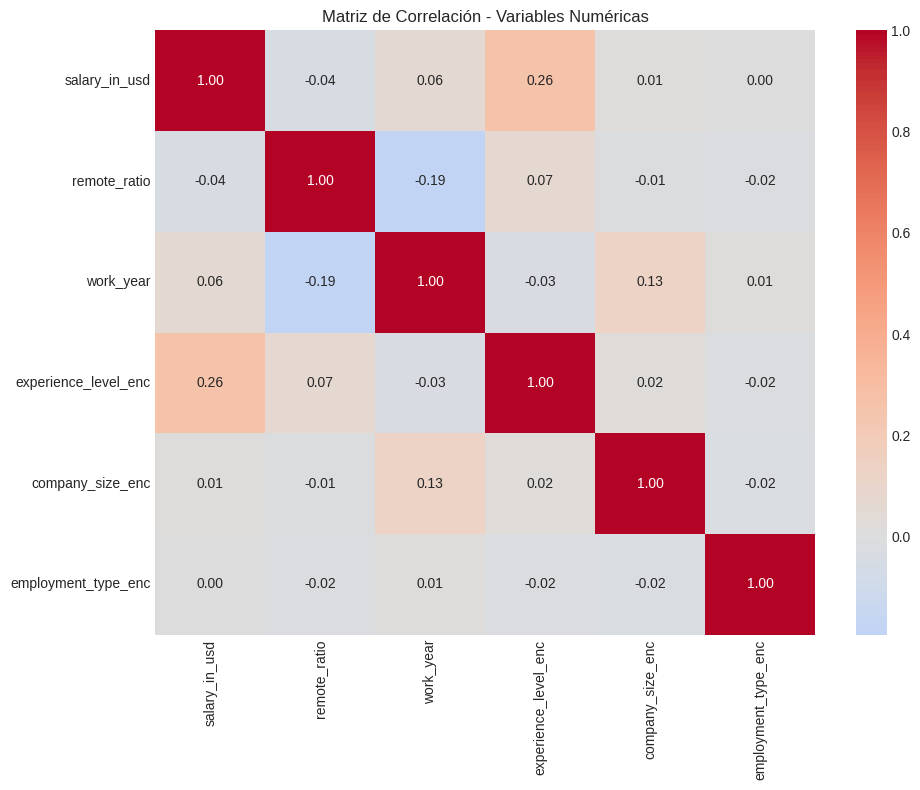

 Matriz de correlación guardada como 'correlacion.png'


In [15]:
print("MATRIZ DE CORRELACIÓN")

# Seleccionar columnas numéricas relevantes
numeric_cols = ['salary_in_usd', 'remote_ratio', 'work_year']
df_numeric = df[numeric_cols].copy()

# Agregar variables codificadas
label_enc = LabelEncoder()
for col in ['experience_level', 'company_size', 'employment_type']:
    df_numeric[col + '_enc'] = label_enc.fit_transform(df[col].astype(str))

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Matriz de correlación guardada como 'correlacion.png'")

**4.2 GRÁFICOS AVANZADOS**

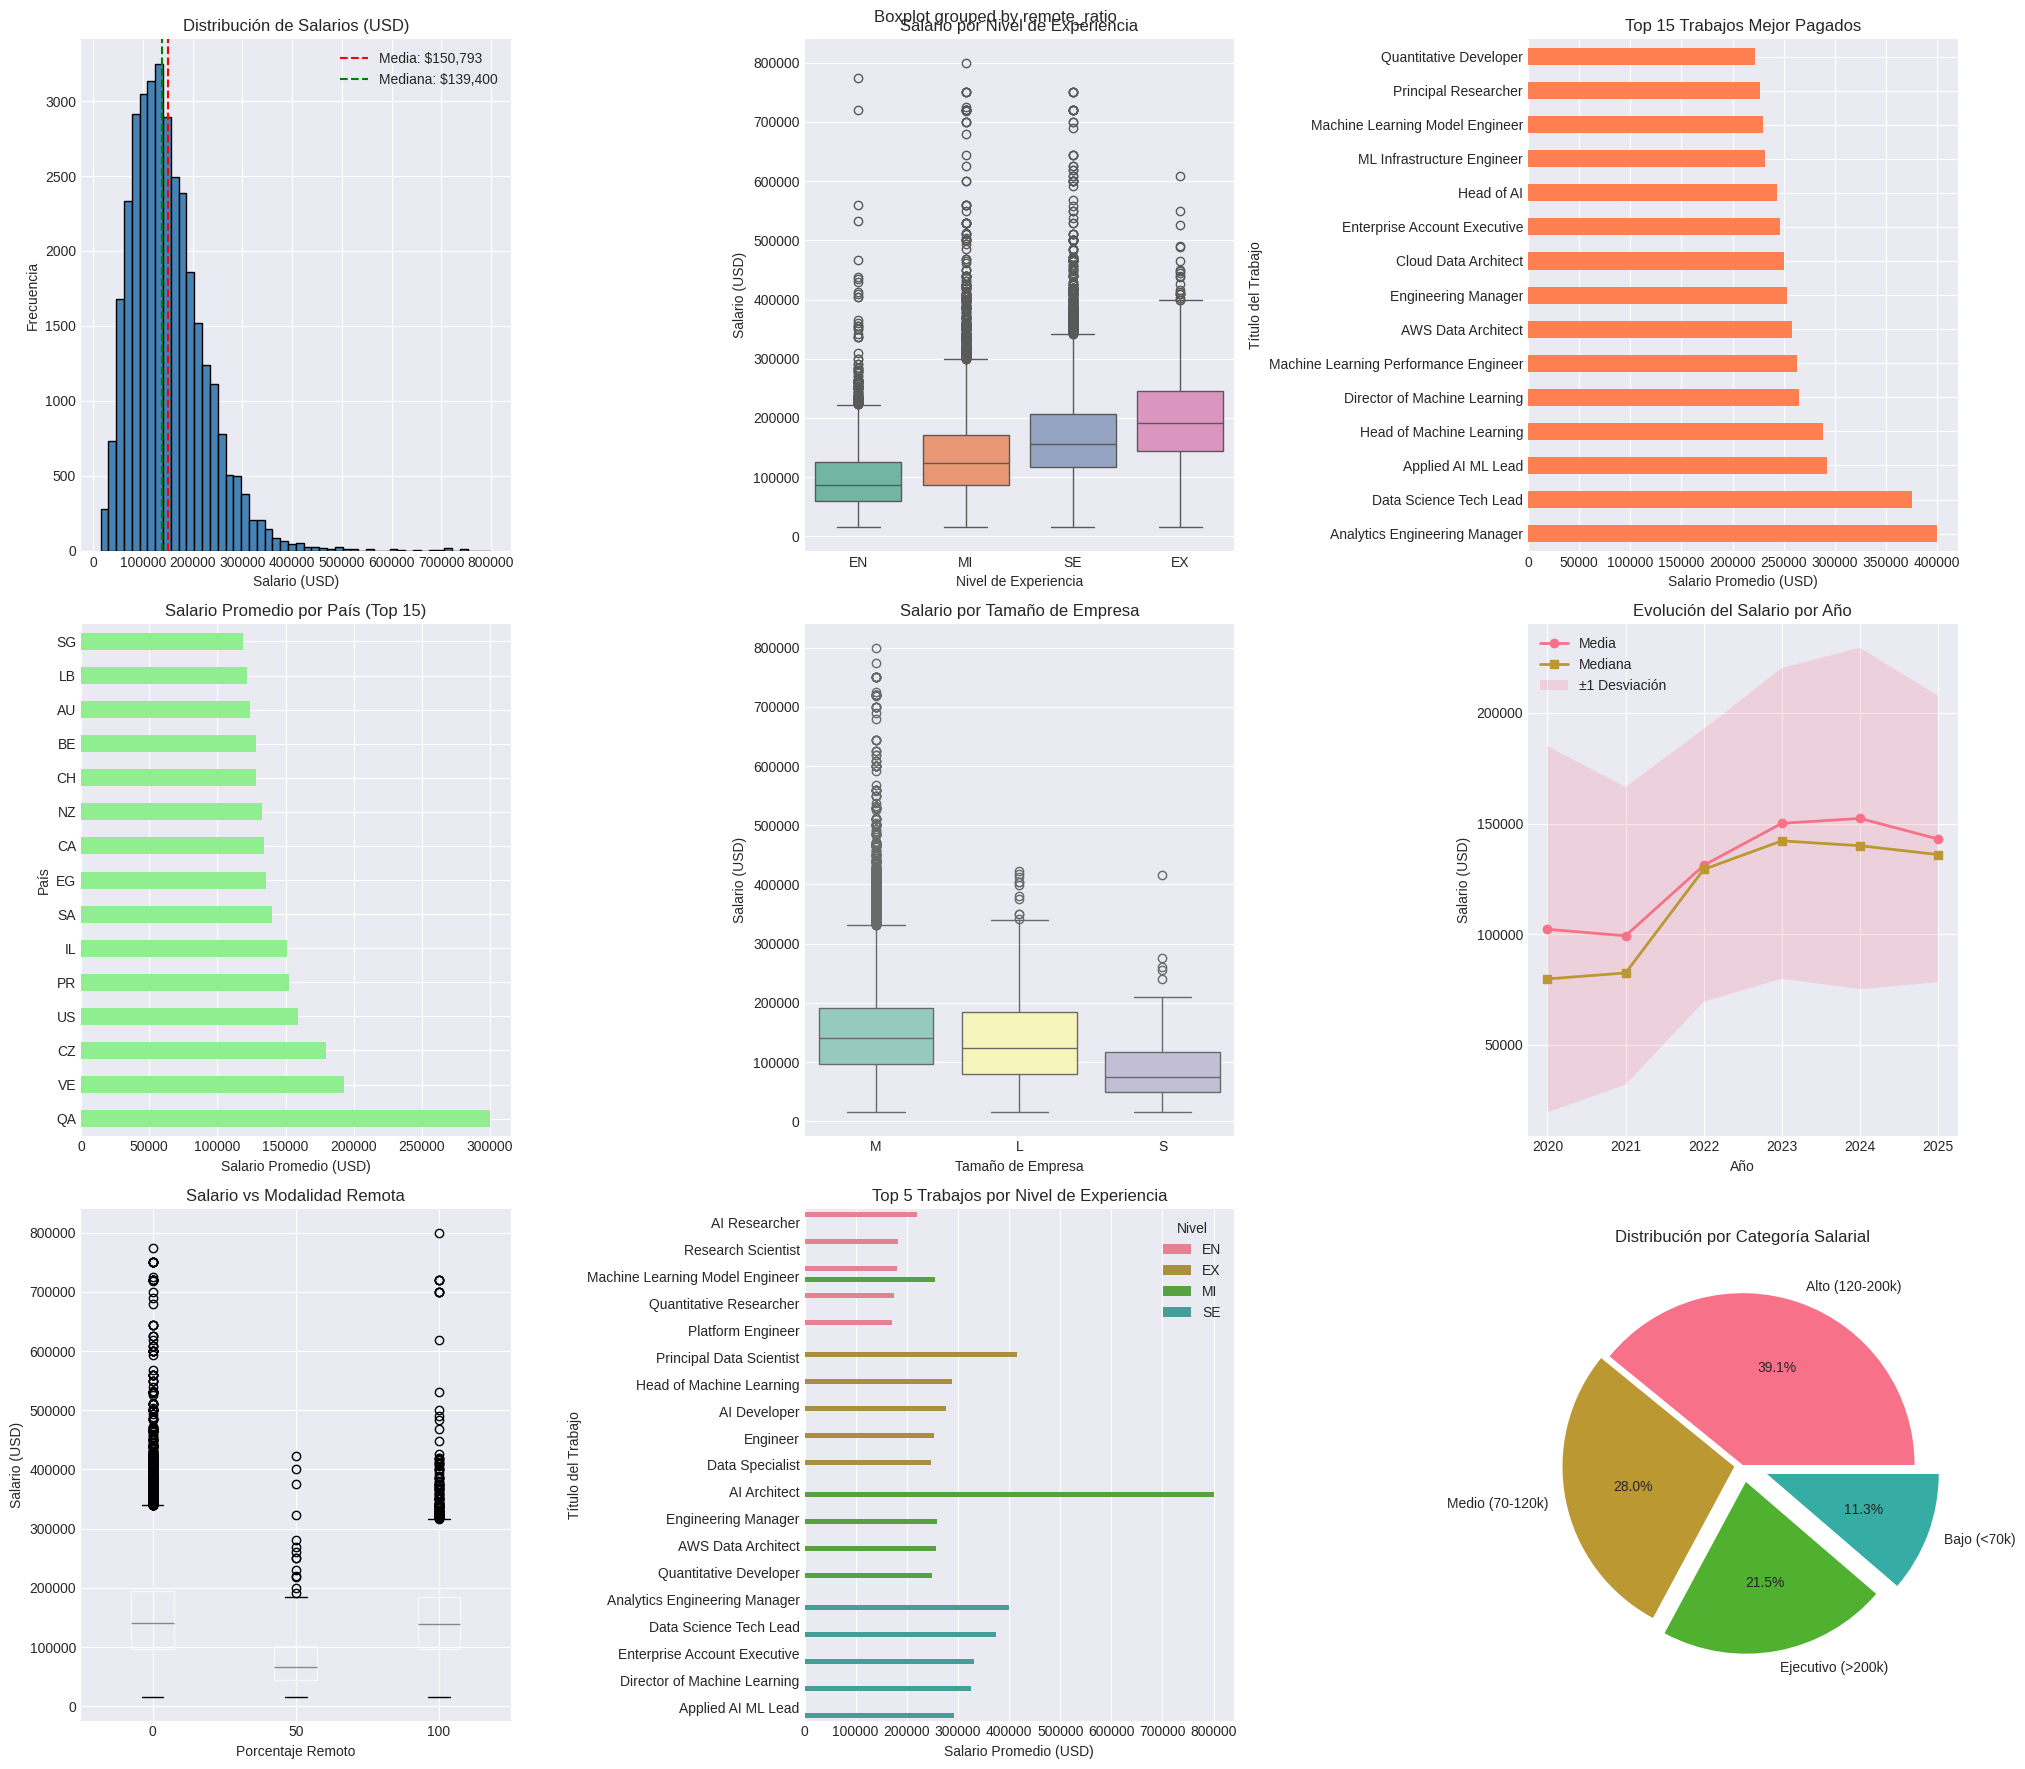

 Gráficos completos guardados como 'analisis_salarios_completo.png'


In [16]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# 1. Distribución de salarios
ax1 = axes[0, 0]
df['salary_in_usd'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='black')
ax1.axvline(df['salary_in_usd'].mean(), color='red', linestyle='--', label=f'Media: ${df["salary_in_usd"].mean():,.0f}')
ax1.axvline(df['salary_in_usd'].median(), color='green', linestyle='--', label=f'Mediana: ${df["salary_in_usd"].median():,.0f}')
ax1.set_title('Distribución de Salarios (USD)')
ax1.set_xlabel('Salario (USD)')
ax1.set_ylabel('Frecuencia')
ax1.legend()

# 2. Salario por nivel de experiencia
ax2 = axes[0, 1]
order = ['EN', 'MI', 'SE', 'EX']
sns.boxplot(x='experience_level', y='salary_in_usd', data=df, order=order, ax=ax2, palette='Set2')
ax2.set_title('Salario por Nivel de Experiencia')
ax2.set_xlabel('Nivel de Experiencia')
ax2.set_ylabel('Salario (USD)')

# 3. Top 15 trabajos mejor pagados
ax3 = axes[0, 2]
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(15)
top_jobs.plot(kind='barh', ax=ax3, color='coral')
ax3.set_title('Top 15 Trabajos Mejor Pagados')
ax3.set_xlabel('Salario Promedio (USD)')
ax3.set_ylabel('Título del Trabajo')

# 4. Salario por país (top 15)
ax4 = axes[1, 0]
top_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(15)
top_countries.plot(kind='barh', ax=ax4, color='lightgreen')
ax4.set_title('Salario Promedio por País (Top 15)')
ax4.set_xlabel('Salario Promedio (USD)')
ax4.set_ylabel('País')

# 5. Salario por tamaño de empresa
ax5 = axes[1, 1]
sns.boxplot(x='company_size', y='salary_in_usd', data=df, ax=ax5, palette='Set3')
ax5.set_title('Salario por Tamaño de Empresa')
ax5.set_xlabel('Tamaño de Empresa')
ax5.set_ylabel('Salario (USD)')

# 6. Evolución temporal de salarios
ax6 = axes[1, 2]
yearly_stats = df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median', 'std']).reset_index()
ax6.plot(yearly_stats['work_year'], yearly_stats['mean'], marker='o', linewidth=2, label='Media')
ax6.plot(yearly_stats['work_year'], yearly_stats['median'], marker='s', linewidth=2, label='Mediana')
ax6.fill_between(yearly_stats['work_year'],
                 yearly_stats['mean'] - yearly_stats['std'],
                 yearly_stats['mean'] + yearly_stats['std'],
                 alpha=0.2, label='±1 Desviación')
ax6.set_title('Evolución del Salario por Año')
ax6.set_xlabel('Año')
ax6.set_ylabel('Salario (USD)')
ax6.legend()

# 7. Relación remoto vs salario
ax7 = axes[2, 0]
df.boxplot(column='salary_in_usd', by='remote_ratio', ax=ax7)
ax7.set_title('Salario vs Modalidad Remota')
ax7.set_xlabel('Porcentaje Remoto')
ax7.set_ylabel('Salario (USD)')

# 8. Top 5 trabajos por nivel de experiencia
ax8 = axes[2, 1]
exp_titles = df.groupby(['experience_level', 'job_title'])['salary_in_usd'].mean().reset_index()
top_exp = exp_titles.sort_values(['experience_level', 'salary_in_usd'], ascending=[True, False])
top_exp = top_exp.groupby('experience_level').head(5)
sns.barplot(x='salary_in_usd', y='job_title', hue='experience_level', data=top_exp, ax=ax8)
ax8.set_title('Top 5 Trabajos por Nivel de Experiencia')
ax8.set_xlabel('Salario Promedio (USD)')
ax8.set_ylabel('Título del Trabajo')
ax8.legend(title='Nivel')

# 9. Distribución por categoría de salario
ax9 = axes[2, 2]
df_encoded['salary_category'].value_counts().plot(kind='pie', ax=ax9, autopct='%1.1f%%', explode=[0, 0.05, 0.1, 0.15])
ax9.set_title('Distribución por Categoría Salarial')
ax9.set_ylabel('')

plt.tight_layout()
plt.savefig('analisis_salarios_completo.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficos completos guardados como 'analisis_salarios_completo.png'")

**4.3 MODELADO PREDICTIVO MEJORADO**

In [17]:
print("FASE 4: MINERÍA DE DATOS - MODELADO PREDICTIVO")

# Preparar datos para modelos
# Usar una selección más completa de variables
feature_cols = [col for col in df_encoded.columns if col.startswith('experience_level_') or
                col.startswith('employment_type_') or
                col.startswith('company_size_') or
                col.startswith('job_title_') or
                col.startswith('employee_residence_') or
                col.startswith('company_location_')]

# También incluir variables numéricas
feature_cols += ['remote_ratio', 'work_year']

# Asegurar que todas existen
feature_cols = [col for col in feature_cols if col in df_encoded.columns]

X = df_encoded[feature_cols]
y = df_encoded['salary_in_usd']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Tamaño de entrenamiento: {len(X_train)}")
print(f" Tamaño de prueba: {len(X_test)}")

# Modelo 1: Regresión Lineal
print("MODELO 1: REGRESIÓN LINEAL:")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_lr):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.2f}")

# Modelo 2: Árbol de Decisión
print("MODELO 2: ÁRBOL DE DECISIÓN:")
dt = DecisionTreeRegressor(max_depth=15, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred_dt):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_dt):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_dt)):,.2f}")

# Modelo 3: Random Forest
print("MODELO 3: RANDOM FOREST:")
rf = RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_split=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_rf):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.2f}")

# Comparación de modelos
print("COMPARACIÓN DE MODELOS:")
model_comparison = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'R²': [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_rf)],
    'MAE': [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_dt), mean_absolute_error(y_test, y_pred_rf)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_dt)), np.sqrt(mean_squared_error(y_test, y_pred_rf))]
})
print(model_comparison.round(2))

# Importancia de características (Random Forest)
print("\n TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Random Forest):")
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(feature_importance)

FASE 4: MINERÍA DE DATOS - MODELADO PREDICTIVO
 Tamaño de entrenamiento: 27219
 Tamaño de prueba: 6805
MODELO 1: REGRESIÓN LINEAL:
R²: 0.2751
MAE: $47,118.38
RMSE: $64,243.59
MODELO 2: ÁRBOL DE DECISIÓN:
R²: 0.2512
MAE: $47,729.19
RMSE: $65,292.11
MODELO 3: RANDOM FOREST:
R²: 0.2594
MAE: $47,420.65
RMSE: $64,935.83
COMPARACIÓN DE MODELOS:
              Modelo    R²       MAE      RMSE
0   Regresión Lineal  0.28  47118.38  64243.59
1  Árbol de Decisión  0.25  47729.19  65292.11
2      Random Forest  0.26  47420.65  64935.83

 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Random Forest):
                                 Feature  Importance
383                employee_residence_US    0.227170
293                  experience_level_SE    0.151685
291                  experience_level_EX    0.080169
84                job_title_Data Analyst    0.071932
292                  experience_level_MI    0.061401
169        job_title_Engineering Manager    0.039371
194  job_title_Machine Learning Engineer  

**4.4 CLUSTERING MEJORADO**

FASE 4: MINERÍA DE DATOS - CLUSTERING MEJORADO


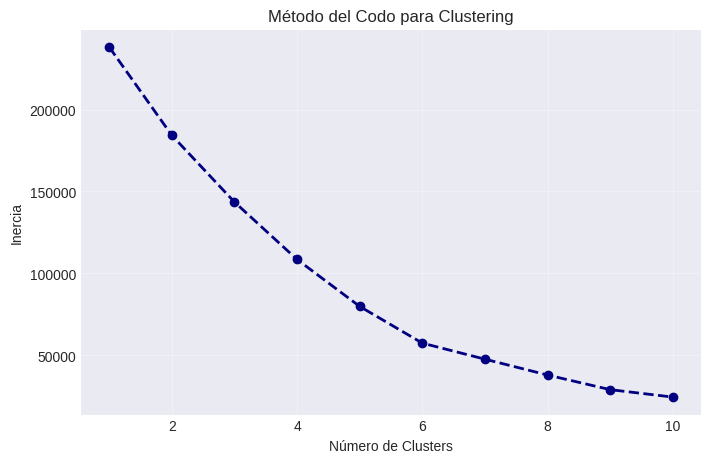

 Gráfico del codo guardado como 'metodo_codo_mejorado.png'

 ANÁLISIS DE CLUSTERS:
        salary_in_usd                       remote_ratio work_year
                 mean    min     max  count         mean      mean
cluster                                                           
0           155525.21  15000  774000  21907        27.18   2023.78
1           137672.17  15000  800000  10864        22.94   2023.84
2            87812.43  15809  416000    203        65.52   2022.16
3           199992.50  15000  609000   1050        23.62   2023.72


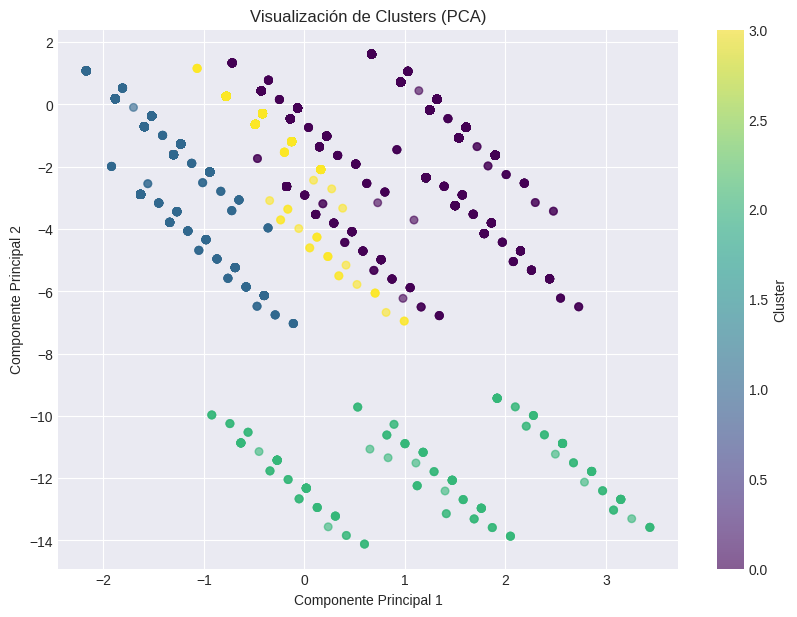

 Visualización de clusters guardada como 'clustering_mejorado.png'


In [18]:
print("FASE 4: MINERÍA DE DATOS - CLUSTERING MEJORADO")

# Preparar datos para clustering con múltiples variables
cluster_vars = ['remote_ratio', 'work_year']
cluster_vars += [col for col in df_encoded.columns if col.startswith('experience_level_')]
cluster_vars += [col for col in df_encoded.columns if col.startswith('company_size_')]
cluster_vars = [col for col in cluster_vars if col in df_encoded.columns]

cluster_data = df_encoded[cluster_vars].copy()

# Escalar datos de clustering
cluster_scaler = StandardScaler()
cluster_data_scaled = cluster_scaler.fit_transform(cluster_data)

# Encontrar número óptimo de clusters
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_data_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o', linestyle='--', color='navy', linewidth=2)
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo para Clustering')
plt.grid(True, alpha=0.3)
plt.savefig('metodo_codo_mejorado.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Gráfico del codo guardado como 'metodo_codo_mejorado.png'")

# Aplicar K-Means con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_encoded['cluster'] = kmeans.fit_predict(cluster_data_scaled)

# Análisis de clusters
print("\n ANÁLISIS DE CLUSTERS:")
cluster_analysis = df_encoded.groupby('cluster').agg({
    'salary_in_usd': ['mean', 'min', 'max', 'count'],
    'remote_ratio': 'mean',
    'work_year': 'mean'
}).round(2)
print(cluster_analysis)

# Visualización de clusters (PCA)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_data_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                     c=df_encoded['cluster'], cmap='viridis', alpha=0.6, s=30)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualización de Clusters (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.savefig('clustering_mejorado.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Visualización de clusters guardada como 'clustering_mejorado.png'")